In [18]:
import biogeme.database as db
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from biogeme import models
from biogeme.biogeme import BIOGEME
from biogeme.expressions import Beta, Variable
from biogeme.results_processing.estimation_results import calculates_correlation_matrix

<Axes: xlabel='valor_operacion', ylabel='fraccionamiento'>

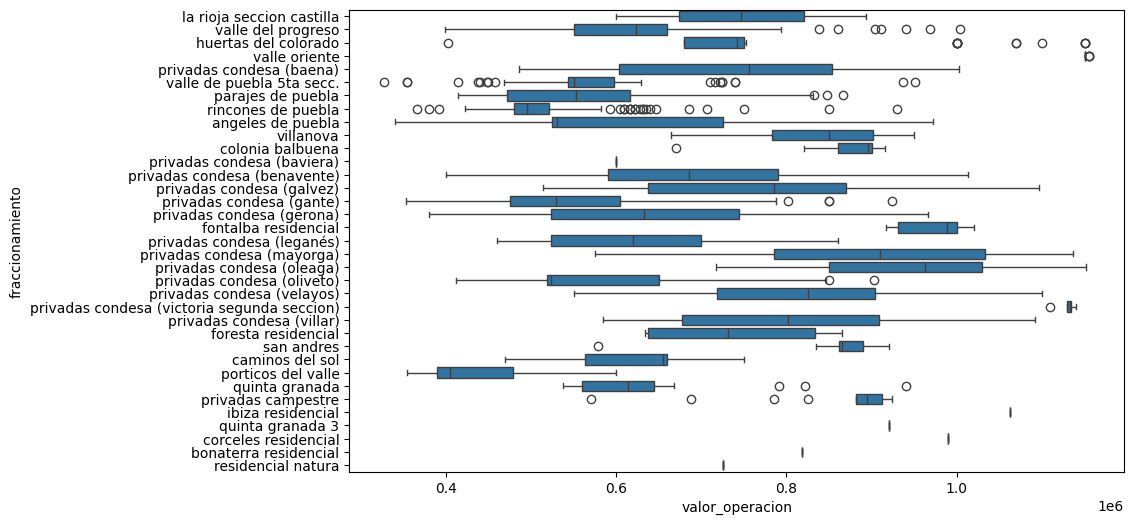

In [19]:
df_transactions = pd.read_parquet("./merged.parquet")

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df_transactions, x="valor_operacion", y="fraccionamiento")

* Costo
* Superficie
* Parques
* Distancia a la frontera
* Baldíos y parques a 5 minutos

In [2]:
df_transactions = pd.read_parquet("./merged.parquet")

unused_frac = df_transactions["fraccionamiento"].value_counts()
unused_frac = unused_frac[unused_frac < 10].index
df_transactions = df_transactions.loc[
    lambda df: ~df["fraccionamiento"].isin(unused_frac)
]

cat = df_transactions["fraccionamiento"].astype("category")
label_to_frac_map = dict(enumerate(cat.cat.categories))
frac_to_label_map = {v: k for k, v in label_to_frac_map.items()}

df_transactions = df_transactions[["fraccionamiento"]].assign(
    fraccionamiento=lambda df: df["fraccionamiento"].map(frac_to_label_map)
)

In [3]:
df_frac_features = gpd.read_parquet("./cols.geoparquet").drop(columns=["geometry"])

df_frac_features = (
    df_frac_features.reset_index(names="fraccionamiento")
    .assign(fraccionamiento=lambda df: df["fraccionamiento"].map(frac_to_label_map))
    .dropna(subset=["fraccionamiento"])
    .assign(fraccionamiento=lambda df: df["fraccionamiento"].astype(int))
    .set_index("fraccionamiento")
)

In [4]:
feature_dict = {}
for col in df_frac_features.columns:
    for idx, val in df_frac_features[col].items():
        feature_dict[f"{col}_{idx}"] = val

for col_name, value in feature_dict.items():
    df_transactions[col_name] = value

df_transactions = df_transactions.copy()  # Defragment DataFrame

C:\Users\lain\AppData\Local\Temp\ipykernel_30532\623320871.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_transactions[col_name] = value
C:\Users\lain\AppData\Local\Temp\ipykernel_30532\623320871.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_transactions[col_name] = value
C:\Users\lain\AppData\Local\Temp\ipykernel_30532\623320871.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

In [11]:
df_transactions

,fraccionamiento,tree_coverage_frac_0,tree_coverage_frac_1,tree_coverage_frac_2,tree_coverage_frac_3,tree_coverage_frac_4,tree_coverage_frac_5,tree_coverage_frac_6,tree_coverage_frac_7,tree_coverage_frac_8,...,travel_time_to_center_15,travel_time_to_center_16,travel_time_to_center_17,travel_time_to_center_18,travel_time_to_center_19,travel_time_to_center_20,travel_time_to_center_21,travel_time_to_center_22,travel_time_to_center_23,travel_time_to_center_24
2,22,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429
3,22,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429
4,22,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429
5,22,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429
6,22,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7128,5,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429
7129,5,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429
7130,6,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429
7131,0,0.017377,0.009797,0.031735,0.00216,0.0,0.001291,0.0,0.0,0.0,...,1126.683998,1136.895622,1161.925881,700.320208,1115.810612,613.920218,967.400613,739.536661,912.70865,307.86429


In [5]:
database = db.Database("housing_choice_model", df_transactions)

choice = Variable("fraccionamiento")

betas = {
    f"beta_{col}": Beta(f"beta_{col}", 0, None, None, 0)
    for col in df_frac_features.columns
}

V = {}
av = {}
for i in range(len(df_frac_features)):
    var_map = {
        f"var_{col}_{i}": Variable(f"{col}_{i}") for col in df_frac_features.columns
    }
    V[i] = sum(
        betas[f"beta_{col}"] * var_map[f"var_{col}_{i}"]
        for col in df_frac_features.columns
    )
    av[i] = 1

logprob = models.loglogit(V, av, choice)
biogeme_model = BIOGEME(
    database,
    logprob,
    parameters="./params/test_1.yaml",
    generate_yaml=False,
    generate_html=True,
    save_iterations=False,
)
biogeme_model.model_name = "test_1"

results = biogeme_model.estimate()

In [6]:
cov = results.robust_variance_covariance_matrix
calculates_correlation_matrix(cov)[0, 1]

np.float64(-0.2806624027796421)

In [7]:
print(results.short_summary())

Results for model test_1
Nbr of parameters:		6
Sample size:			7106
Excluded data:			0
Final log likelihood:		-20167.2
Akaike Information Criterion:	40346.41
Bayesian Information Criterion:	40387.62



<Axes: >

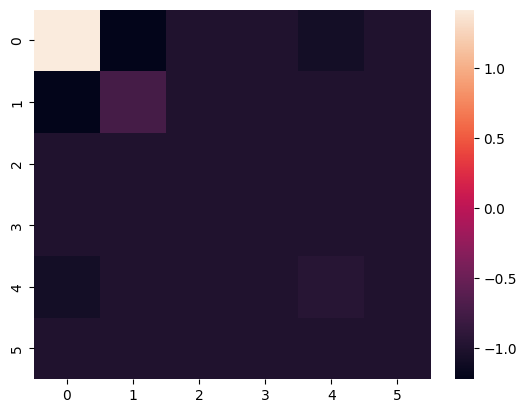

In [8]:
sns.heatmap(results.robust_variance_covariance_matrix - 1)

In [9]:
print(results.get_estimated_parameters())

                         Name      Value  Robust std err.  Robust t-stat.  \
0     beta_tree_coverage_frac -15.251315         1.554007       -9.814187   
1    beta_urbanized_area_frac  -1.685049         0.505105       -3.336037   
2                   beta_jobs  -0.000058         0.000012       -4.990521   
3       beta_jobs_manufacture   0.000047         0.000031        1.530292   
4          beta_accessibility   3.576311         0.224029       15.963615   
5  beta_travel_time_to_center   0.004175         0.000399       10.463942   

   Robust p-value  
0    0.000000e+00  
1    8.498198e-04  
2    6.021654e-07  
3    1.259444e-01  
4    0.000000e+00  
5    0.000000e+00  


C:\Users\lain\AppData\Local\Temp\ipykernel_30532\2081322227.py:1: DeprecationWarning: get_estimated_parameters is deprecated. Use get_pandas_estimated_parameters(estimation_results=my_results) instead
  print(results.get_estimated_parameters())
